In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_data = pd.read_csv(r'C:\Users\LOQ\Desktop\Machine Learning\Linear Regression\data\raw\insurance.csv')
raw_data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data = raw_data.copy()

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print(data.shape)
print('='*50)
print(data.info())
print('='*50)
print(data.describe())

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max     

In [6]:
print("Duplicates:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)

Duplicates: 1


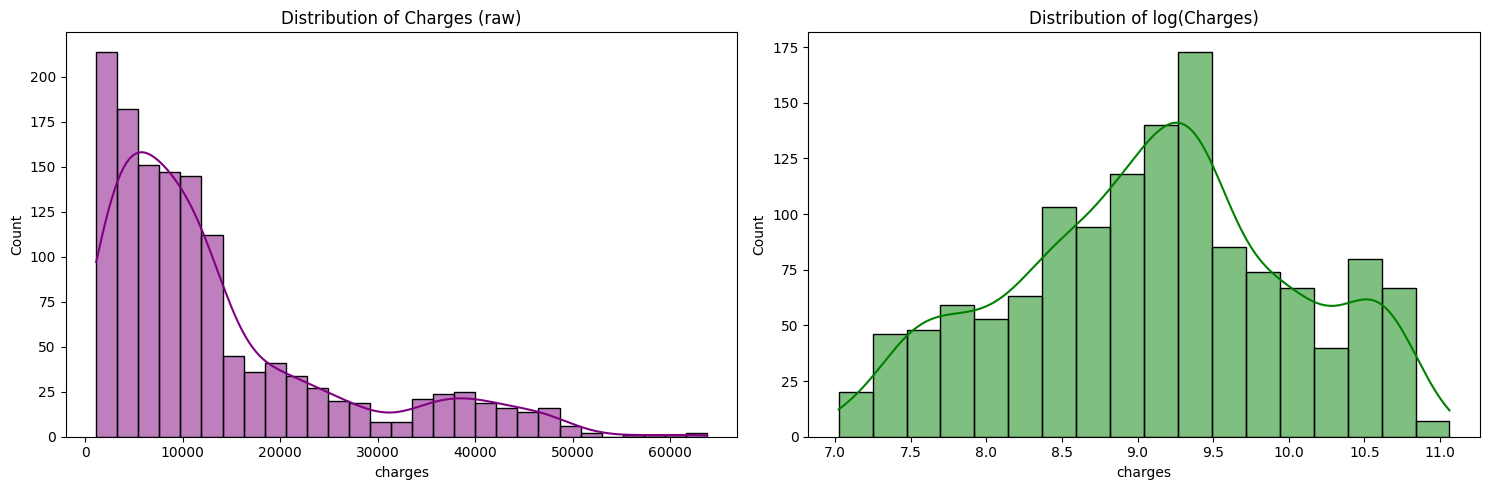

Charges skew: 1.52
log(Charges) skew: -0.09


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['charges'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Charges (raw)')

sns.histplot(np.log1p(data['charges']), kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of log(Charges)')

plt.tight_layout()
plt.show()

print("Charges skew:", round(data['charges'].skew(), 2))
print("log(Charges) skew:", round(np.log1p(data['charges']).skew(), 2))

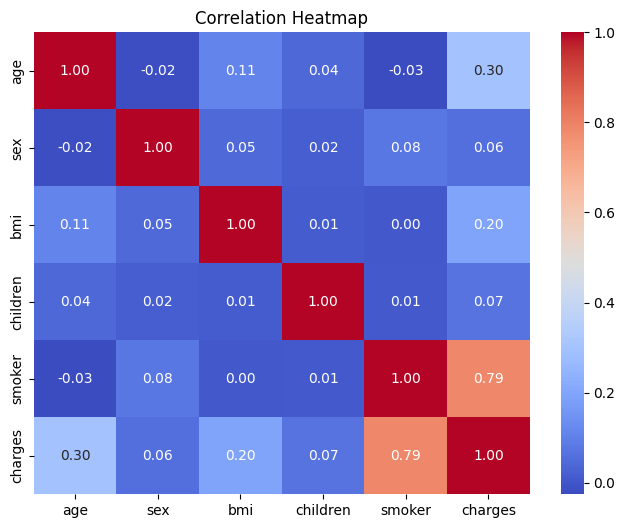

In [8]:
# encode the simple binary categoricals just for correlation
corr_data = data.copy()
corr_data['smoker'] = (corr_data['smoker'] == 'yes').astype(int)
corr_data['sex'] = (corr_data['sex'] == 'male').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

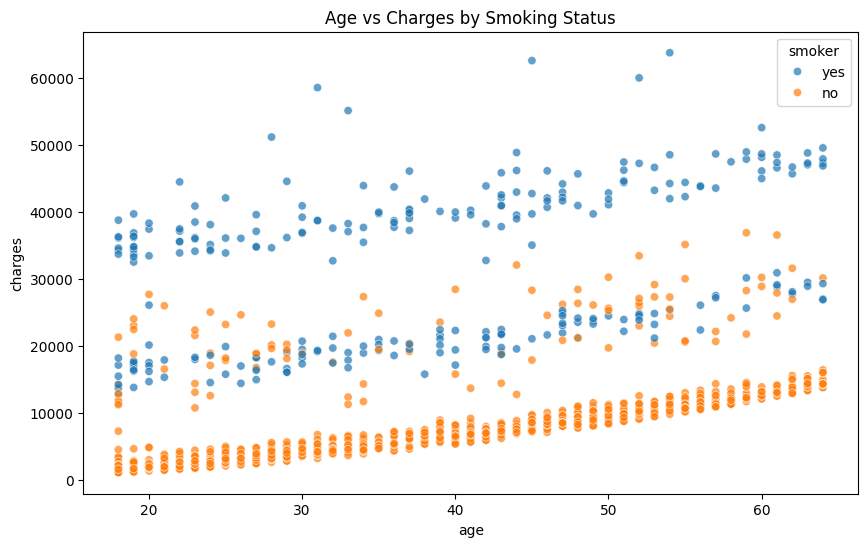

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Age vs Charges by Smoking Status')
plt.show()

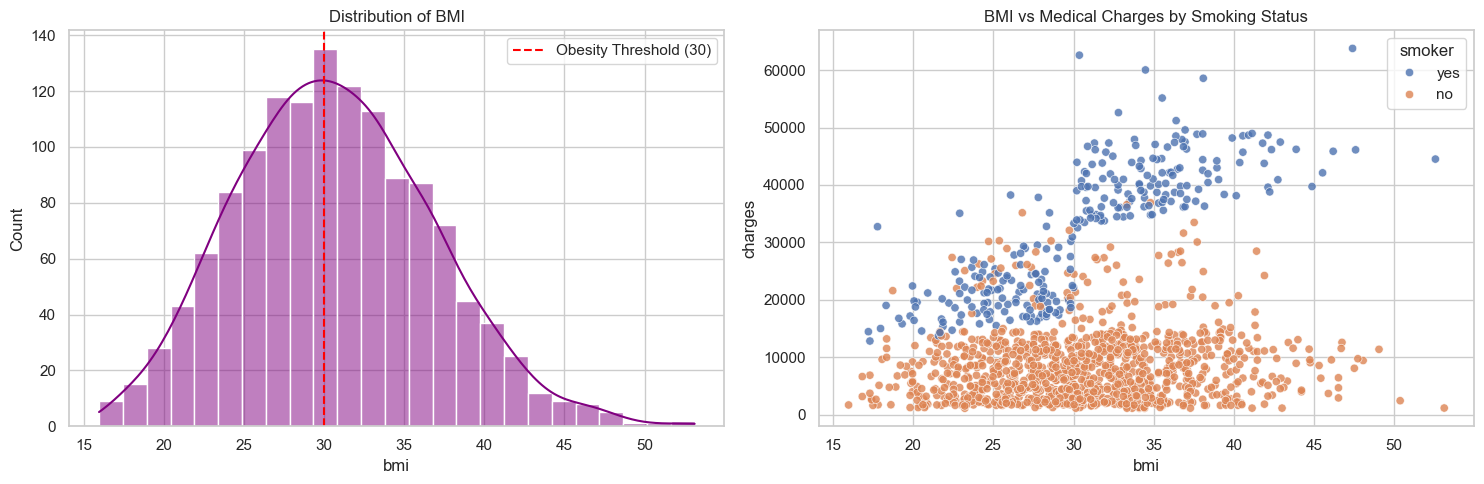

In [10]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution Plot
sns.histplot(data=data, x="bmi", kde=True, ax=axes[0], color="purple")
axes[0].set_title("Distribution of BMI")
axes[0].axvline(30, color="red", linestyle="--", label="Obesity Threshold (30)")
axes[0].legend()

# 2. Scatter Plot with Smoker Hue
sns.scatterplot(data=data, x="bmi", y="charges", hue="smoker", alpha=0.8, ax=axes[1])
axes[1].set_title("BMI vs Medical Charges by Smoking Status")

plt.tight_layout()
plt.show()


In [11]:
print("Sex %:\n", (data['sex'].value_counts(normalize=True) * 100).round(2))
print("\nSmoker %:\n", (data['smoker'].value_counts(normalize=True) * 100).round(2))

Sex %:
 sex
male      50.49
female    49.51
Name: proportion, dtype: float64

Smoker %:
 smoker
no     79.51
yes    20.49
Name: proportion, dtype: float64


In [12]:
# Create a smart feature that flags this specific high-cost risk zone
data['is_smoker_and_obese'] = ((data['bmi'] >= 30) & (data['smoker'] == 'yes')).astype(int)


In [13]:
data.groupby('sex')['smoker'].value_counts()

sex     smoker
female  no        547
        yes       115
male    no        516
        yes       159
Name: count, dtype: int64

In [14]:
# Calculate Q1, Q3, and IQR for the BMI column
Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower statistical boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter and extract the rows containing outliers
bmi_outliers = data[(data['bmi'] < lower_bound) | (data['bmi'] > upper_bound)]

print(f"BMI lower bound: {lower_bound:.2f}, upper bound: {upper_bound:.2f}")
print(f"Total BMI outliers found: {len(bmi_outliers)}")
print(bmi_outliers[['age', 'bmi', 'charges']])


BMI lower bound: 13.67, upper bound: 47.32
Total BMI outliers found: 9
      age    bmi      charges
116    58  49.06  11381.32540
286    46  48.07   9432.92530
401    47  47.52   8083.91980
543    54  47.41  63770.42801
846    23  50.38   2438.05520
859    37  47.60  46113.51100
1046   22  52.58  44501.39820
1087   52  47.74   9748.91060
1316   18  53.13   1163.46270


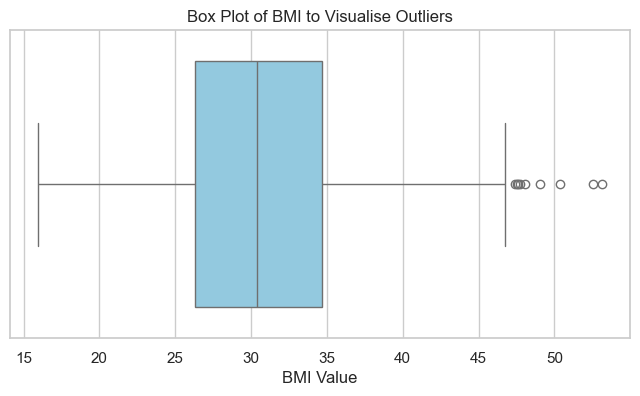

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['bmi'], color='skyblue')
plt.title('Box Plot of BMI to Visualise Outliers')
plt.xlabel('BMI Value')
plt.show()


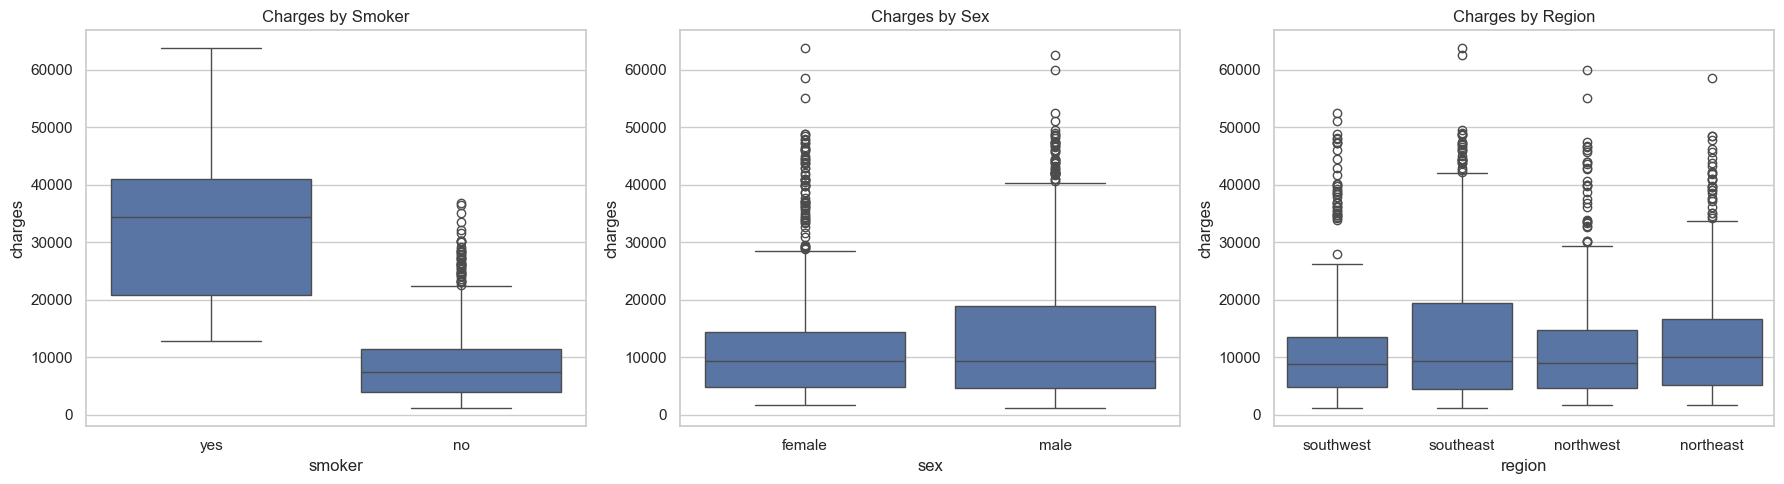

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=data, x='smoker', y='charges', ax=axes[0])
axes[0].set_title('Charges by Smoker')

sns.boxplot(data=data, x='sex', y='charges', ax=axes[1])
axes[1].set_title('Charges by Sex')

sns.boxplot(data=data, x='region', y='charges', ax=axes[2])
axes[2].set_title('Charges by Region')

plt.tight_layout()
plt.show()

In [17]:
X = data.drop(columns=['charges'])
y = np.log1p(data['charges'])   # log target; invert with expm1 later

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
categorical = ['sex', 'smoker', 'region']
numeric = ['age', 'bmi', 'children', 'is_smoker_and_obese']

In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print("Baseline R²:", r2_score(y_test, dummy.predict(X_test)))  # ~0

Baseline R²: -0.001852867824863269


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical),
    ('num', StandardScaler(), numeric)
])

model = Pipeline([
    ('prep', preprocess),
    ('lr', LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)            # back to dollars
true = np.expm1(y_test)

print("R²:", round(r2_score(y_test, pred_log), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(true, pred)), 2))
print("MAE :", round(mean_absolute_error(true, pred), 2))

R²: 0.844
RMSE: 7740.12
MAE : 3845.84


In [23]:
feat_names = model.named_steps['prep'].get_feature_names_out()
coefs = model.named_steps['lr'].coef_
print(pd.Series(coefs, index=feat_names).sort_values(ascending=False))

cat__smoker_yes             1.208884
num__age                    0.480736
num__is_smoker_and_obese    0.195983
num__children               0.119436
num__bmi                    0.024778
cat__region_northwest      -0.035339
cat__sex_male              -0.089351
cat__region_southwest      -0.116637
cat__region_southeast      -0.119281
dtype: float64


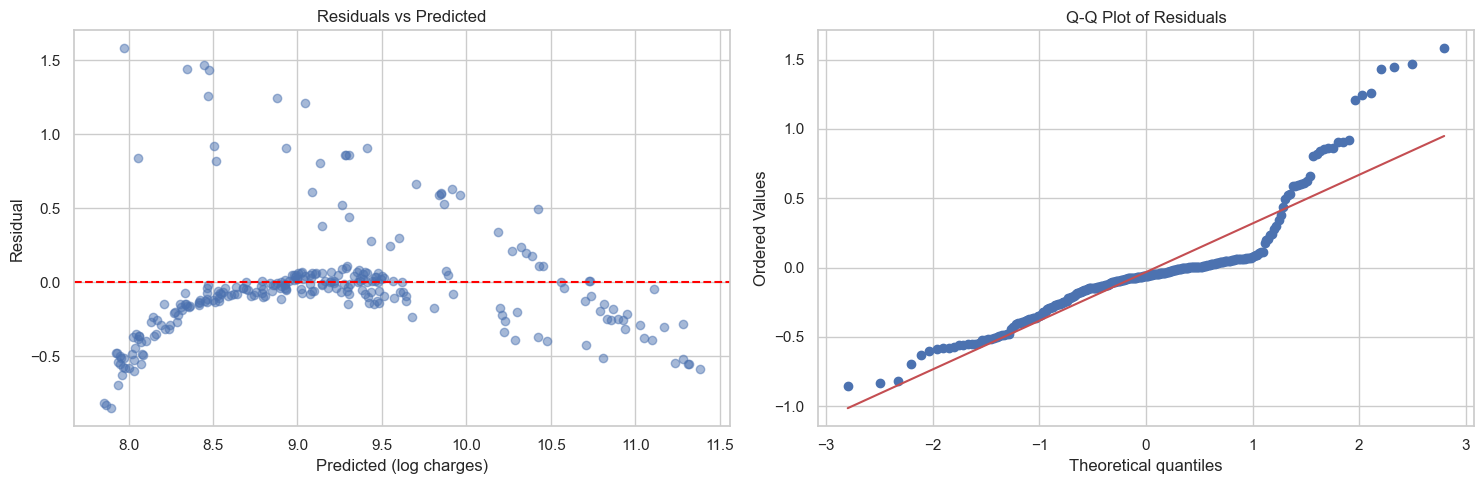

In [24]:
residuals = y_test - pred_log   # work in the space the model was trained on

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Residuals vs predicted — should be a shapeless cloud around 0
axes[0].scatter(pred_log, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted (log charges)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# 2. Q-Q plot — points should hug the diagonal if residuals are normal
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [25]:
import joblib
joblib.dump(model, 'insurance_model.pkl')
print("Saved.")

Saved.
